# **FICO® Xpress MoselPy - Chapter D: Loading and Cutting Stock**

***loading_cutting_stock.ipynb*** - Loading and cutting stock problems from the Xpress Applications Book - wagon load balancing, ship loading, tank filling, bin packing, and cutting stock, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
import moselpy as mp
from moselpy import ExecStatus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/loading_cutting_stock"
DATA   = "data/loading_cutting_stock"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Loading and cutting stock problems

This notebook covers six MIP examples from Chapter D of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples range from bin-packing and assignment problems (wagon loading, tank filling, file backup) to cutting-stock problems (sheet metal, steel bars).

> **Mosel source files:** [`models/loading_cutting_stock/`](models/loading_cutting_stock/) &nbsp;|&nbsp; **Data files:** [`data/loading_cutting_stock/`](data/loading_cutting_stock/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_4)

### MoselPy features demonstrated in this chapter

- **LP/MIP file export**: D-1 calls `model.export_problem(file_name=...)` after solving to write a human-readable LP file for inspection or re-use.
- **Warm-start via `addmipsol`**: D-1 (variant 2) feeds a Python-computed LPT heuristic solution into the MIP solver as an initial integer solution via `addmipsol`.
- **Parametric variant selection**: D-2 accepts a `VARIANT` parameter selecting one of three progressively constrained LP/MIP formulations; all three run from Python in the compile-load-run sequence.
- **`pd.DataFrame` for 2D input**: D-5 receives the 4x16 cutting matrix as a DataFrame; MoselPy maps row and column indices to the Mosel 2D array.

## D-1 Wagon load balancing (MIP)

*Applications Book Chapter D, Example 1*

> **Mosel models:** [`d1wagon_p.mos`](models/loading_cutting_stock/d1wagon_p.mos), [`d1wagon2_p.mos`](models/loading_cutting_stock/d1wagon2_p.mos)

Sixteen boxes of varying weights must be loaded onto three railway wagons. Each wagon has a weight capacity of 100 quintals. The goal is to assign boxes to wagons so that the heaviest wagon load is minimized (a minimax objective).

**Sets:** $\text{BOXES} = 1..16$, $\text{WAGONS} = 1..3$

**Decision variables:** $\mathit{ifload}_{b,w} \in \{0,1\}$ (1 if box $b$ goes to wagon $w$); $\mathit{maxweight} \geq 0$ (heaviest load)

$$
\begin{align*}
\text{minimize}   \quad & \mathit{maxweight} \\
\text{subject to} \quad & \sum_{w} \mathit{ifload}_{b,w} = 1 \quad \forall\, b \quad \text{(each box in one wagon)} \\
                          & \sum_{b} \text{WEIGHT}_b \cdot \mathit{ifload}_{b,w} \leq \mathit{maxweight} \quad \forall\, w \\
                          & \mathit{maxweight} \leq \text{WMAX} \\
                          & \mathit{maxweight} \geq \left\lceil \frac{\sum_b \text{WEIGHT}_b}{3} \right\rceil
\end{align*}
$$

Define the 16 box weights and the wagon capacity limit in Python. Both are 1-indexed dicts.

In [ ]:
WEIGHT = {i+1: v for i,v in enumerate([34,6,8,17,16,5,13,21,25,31,14,13,33,9,25,25])}
WMAX   = 100

Use the compile-load-run sequence. After `run()`, `model.export_problem(file_name=...)` writes the MIP formulation to an LP file. Pass the path as a keyword argument - the first positional argument is `options` (format flags), not the file name. The LP file is useful for inspecting the formulation in a text editor or external solver.

In [ ]:
mp.compile_model(f"{MODELS}/d1wagon_p.mos", f"{MODELS}/d1wagon_p.bim")
model = mp.load_model(f"{MODELS}/d1wagon_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"WEIGHT": WEIGHT, "WMAX": WMAX},
)

# Export the MIP formulation to LP format after solving (problem must be built first)
model.export_problem(file_name=f"{MODELS}/d1wagon_p.lp")
print("LP file written to models/loading_cutting_stock/d1wagon_p.lp")

if model.prob_status.is_solution_available:
    obj_val    = output["obj_val"]
    sol_ifload = output["sol_ifload"]   # dict: (box, wagon) -> real

    print(f"\nMinimax wagon weight: {obj_val:.0f}")
    print()
    print(f"{'Wagon':<8} {'Boxes':<40} {'Total weight'}")
    for w in range(1, 4):
        boxes = [b for b in range(1, 17) if sol_ifload.get((b, w), 0) > 0.5]
        total = sum(WEIGHT[b] for b in boxes)
        print(f"  {w:<6} {str(boxes):<40} {total}")
else:
    print(f"No solution found ({model.prob_status})")

LP file written to models/loading_cutting_stock/d1wagon_p.lp

Minimax wagon weight: 99

Wagon    Boxes                                    Total weight
  1      [1, 2, 3, 6, 8, 16]                      99
  2      [9, 10, 13, 14]                          98
  3      [4, 5, 7, 11, 12, 15]                    98


Stacked bar chart showing the box assignments across wagons. Each bar is one wagon; segments are individual boxes (width proportional to box weight). The red dashed line marks the WMAX capacity limit.

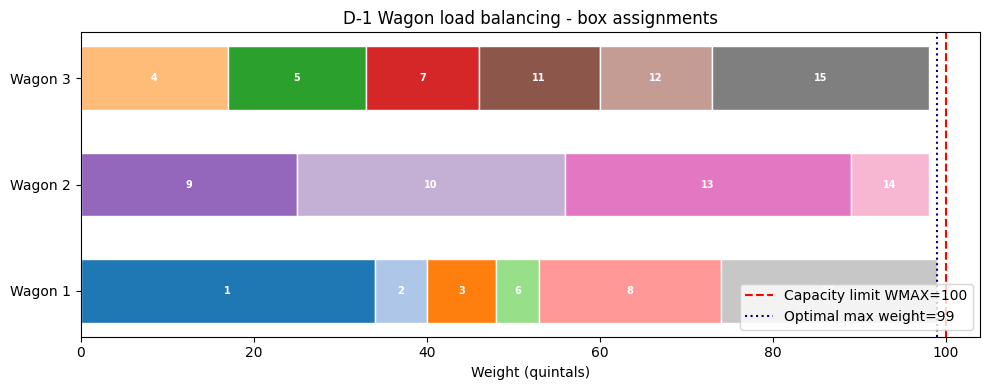

In [ ]:
if "sol_ifload" in locals():
    colors = plt.cm.tab20.colors

    fig, ax = plt.subplots(figsize=(10, 4))
    for w in range(1, 4):
        boxes = sorted([b for b in range(1, 17) if sol_ifload.get((b, w), 0) > 0.5])
        left = 0
        for b in boxes:
            wt = WEIGHT[b]
            ax.barh(w-1, wt, left=left, color=colors[(b-1) % 20], edgecolor="white", height=0.6)
            ax.text(left + wt/2, w-1, str(b), ha="center", va="center",
                    fontsize=7, fontweight="bold", color="white")
            left += wt

    ax.axvline(WMAX, color="red", linestyle="--", linewidth=1.5, label=f"Capacity limit WMAX={WMAX}")
    ax.axvline(obj_val, color="navy", linestyle=":", linewidth=1.5, label=f"Optimal max weight={obj_val:.0f}")
    ax.set_yticks(range(3))
    ax.set_yticklabels([f"Wagon {w}" for w in range(1, 4)])
    ax.set_xlabel("Weight (quintals)")
    ax.set_title("D-1 Wagon load balancing - box assignments")
    ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping wagon chart")

### Warm-start from Python (d1wagon2_p)

`d1wagon2_p.mos` uses a warm start to speed up the MIP. The LPT (Longest Processing Time) heuristic is implemented here in Python: boxes are sorted by weight descending and assigned one by one to the least-loaded wagon. The resulting assignment (`HeurSol`) is passed to Mosel via `input_data`. Inside the model, `addmipsol` feeds it to the Xpress branch-and-bound as an initial integer solution.

This demonstrates a clean MoselPy pattern: **the heuristic lives in Python, the warm-start mechanism lives in Mosel**. The `solnotify` Mosel callback reports whether the optimizer accepted and used the solution.

In [ ]:
# LPT heuristic implemented in Python: sort boxes by weight desc, assign to least-loaded wagon
wagon_loads_h = {1: 0, 2: 0, 3: 0}
heur_sol = {}
for box in sorted(WEIGHT, key=WEIGHT.get, reverse=True):
    wagon = min(wagon_loads_h, key=wagon_loads_h.get)
    heur_sol[box] = wagon
    wagon_loads_h[wagon] += WEIGHT[box]

heur_max = max(wagon_loads_h.values())
print(f"LPT heuristic - max wagon weight: {heur_max}")
for w in range(1, 4):
    boxes_w = sorted(b for b in range(1, 17) if heur_sol[b] == w)
    print(f"  Wagon {w} ({wagon_loads_h[w]} quintals): boxes {boxes_w}")

LPT heuristic - max wagon weight: 101
  Wagon 1 (97 quintals): boxes [1, 3, 5, 11, 16]
  Wagon 2 (97 quintals): boxes [4, 7, 13, 14, 15]
  Wagon 3 (101 quintals): boxes [2, 6, 8, 9, 10, 12]


Run `d1wagon2_p.mos` with the Python-computed `HeurSol` passed via `input_data`. The model feeds it to the optimizer via `addmipsol` before branch-and-bound starts.

In [ ]:
mp.compile_model(f"{MODELS}/d1wagon2_p.mos", f"{MODELS}/d1wagon2_p.bim")
with mp.load_model(f"{MODELS}/d1wagon2_p.bim") as model2:
    model2.set_default_stream(mp.StreamType.OUTPUT, "null:")
    out2 = model2.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"WEIGHT": WEIGHT, "WMAX": WMAX, "HeurSol": heur_sol},
    )
    ok2 = model2.prob_status.is_solution_available
    sol_ifload_opt = out2.get("sol_ifload", {}) if ok2 else {}

if ok2:
    opt_max = out2["obj_val"]
    print(f"LPT heuristic max weight: {heur_max:.0f}")
    print(f"MIP optimal  max weight:  {opt_max:.0f}")
    print(f"Gap closed:  {heur_max - opt_max:.0f} quintals")
else:
    print("No solution found for d1wagon2_p")

LPT heuristic max weight: 101
MIP optimal  max weight:  99
Gap closed:  2 quintals


Side-by-side comparison of the LPT heuristic assignment (left) and the MIP optimal assignment (right). Each row is a wagon; segments represent individual boxes, width proportional to weight.

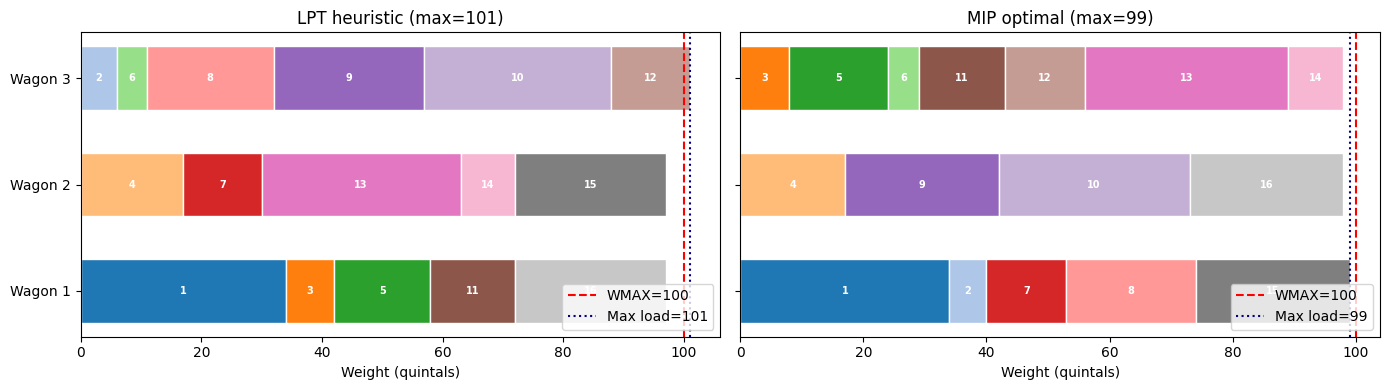

In [ ]:
if ok2:
    colors = plt.cm.tab20.colors
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    def draw_wagons(ax, assignment_fn, title, max_w):
        for w in range(1, 4):
            boxes = sorted(b for b in range(1, 17) if assignment_fn(b) == w)
            left = 0
            for b in boxes:
                wt = WEIGHT[b]
                ax.barh(w-1, wt, left=left, color=colors[(b-1)%20], edgecolor="white", height=0.6)
                ax.text(left + wt/2, w-1, str(b), ha="center", va="center",
                        fontsize=7, fontweight="bold", color="white")
                left += wt
        ax.axvline(WMAX, color="red", linestyle="--", linewidth=1.5, label=f"WMAX={WMAX}")
        ax.axvline(max_w, color="navy", linestyle=":", linewidth=1.5, label=f"Max load={max_w:.0f}")
        ax.set_yticks(range(3)); ax.set_yticklabels([f"Wagon {w}" for w in range(1,4)])
        ax.set_xlabel("Weight (quintals)"); ax.set_title(title); ax.legend(loc="lower right")

    draw_wagons(axes[0], lambda b: heur_sol[b], f"LPT heuristic (max={heur_max:.0f})", heur_max)
    draw_wagons(axes[1], lambda b: round(sum(w*sol_ifload_opt.get((b,w),0) for w in range(1,4))),
                f"MIP optimal (max={out2['obj_val']:.0f})", out2["obj_val"])
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping comparison chart")

## D-2 Ship loading (LP/MIP)

*Applications Book Chapter D, Example 2*

> **Mosel model:** [`d2ship_p.mos`](models/loading_cutting_stock/d2ship_p.mos)

A shipper has 7 clients wishing to ship wheat. Each client offers varying numbers of lots, lot sizes, prices, and transport costs. The shipper maximizes profit subject to a ship capacity constraint. The model accepts a `VARIANT` parameter to select one of three progressively constrained variants:

- **VARIANT=1 (LP):** unlimited lot availability per client.
- **VARIANT=2 (LP):** each client has an upper bound on available lots.
- **VARIANT=3 (MIP):** lots must be integer-valued.

**Sets:** $\text{CLIENTS} = 1..7$

**Decision variables:** $\mathit{loadqty}_c \geq 0$ (lots taken from client $c$)

**Derived parameter:** $\text{PROF}_c = \text{PRICE}_c - \text{COST}_c \cdot \text{SIZE}_c$ (profit per lot from client $c$)

$$
\begin{align*}
\text{maximize}   \quad & \sum_{c} \text{PROF}_c \cdot \mathit{loadqty}_c \\
\text{subject to} \quad & \sum_{c} \text{SIZE}_c \cdot \mathit{loadqty}_c \leq \text{CAP} \\
                          & \mathit{loadqty}_c \leq \text{AVAIL}_c \quad \forall\, c \quad \text{(Problem 2 and 3 only)} \\
                          & \mathit{loadqty}_c \in \mathbb{Z}_{\geq 0} \quad \forall\, c \quad \text{(Problem 3 only)}
\end{align*}
$$

Define client data in Python: available lots `AVAIL`, lot sizes `SIZE`, prices `PRICE`, transport costs `COST`, and ship capacity `CAP`, all as 1-indexed dicts.

In [ ]:
AVAIL = {i+1: v for i,v in enumerate([12,31,20,25,50,40,60])}
SIZE  = {i+1: v for i,v in enumerate([10, 8, 6, 9,15,10,12])}
PRICE = {i+1: v for i,v in enumerate([1000,600,600,800,1200,800,1100])}
COST  = {i+1: v for i,v in enumerate([80,70,85,80,73,70,80])}
CAP   = 1500

# Derived: profit per lot (for display)
PROF = {c: PRICE[c] - COST[c]*SIZE[c] for c in range(1, 8)}
print("Profit per lot by client:")
for c in range(1, 8):
    print(f"  Client {c}: price={PRICE[c]}, cost={COST[c]}, size={SIZE[c]} -> profit={PROF[c]}")

Profit per lot by client:
  Client 1: price=1000, cost=80, size=10 -> profit=200
  Client 2: price=600, cost=70, size=8 -> profit=40
  Client 3: price=600, cost=85, size=6 -> profit=90
  Client 4: price=800, cost=80, size=9 -> profit=80
  Client 5: price=1200, cost=73, size=15 -> profit=105
  Client 6: price=800, cost=70, size=10 -> profit=100
  Client 7: price=1100, cost=80, size=12 -> profit=140


Compile and load `d2ship_p.mos` once, then run it three times with `VARIANT=1`, `VARIANT=2`, and `VARIANT=3`. Each run returns `sol_obj` (the profit for that variant) and `sol_load` (the lots per client). Running separately lets you inspect the solution at each stage rather than only seeing the final MIP result.

In [ ]:
mp.compile_model(f"{MODELS}/d2ship_p.mos", f"{MODELS}/d2ship_p.bim")
model = mp.load_model(f"{MODELS}/d2ship_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

obj_labels = {1: "LP, no limits", 2: "LP, availability limits", 3: "MIP, integer lots"}
results = {}
for obj in [1, 2, 3]:
    output = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "VARIANT": obj},
        input_data={"AVAIL": AVAIL, "SIZE": SIZE, "PRICE": PRICE, "COST": COST, "CAP": CAP},
    )
    if model.prob_status.is_solution_available:
        results[obj] = output
    else:
        print(f"MOD={obj}: No solution found ({model.prob_status})")

for obj, output in results.items():
    sol_obj  = output["sol_obj"]
    sol_load = output["sol_load"]
    print(f"OBJ {obj} ({obj_labels[obj]}): profit = {sol_obj:,.2f}")
    for c in range(1, 8):
        q = sol_load.get(c, 0)
        if q > 0.001:
            print(f"  Client {c}: {q:.4g} lots  (contribution: {PROF[c]*q:,.0f})")
    print()

OBJ 1 (LP, no limits): profit = 30,000.00
  Client 1: 150 lots  (contribution: 30,000)

OBJ 2 (LP, availability limits): profit = 17,844.44
  Client 1: 12 lots  (contribution: 2,400)
  Client 3: 20 lots  (contribution: 1,800)
  Client 4: 15.56 lots  (contribution: 1,244)
  Client 6: 40 lots  (contribution: 4,000)
  Client 7: 60 lots  (contribution: 8,400)

OBJ 3 (MIP, integer lots): profit = 17,805.00
  Client 1: 12 lots  (contribution: 2,400)
  Client 3: 20 lots  (contribution: 1,800)
  Client 4: 15 lots  (contribution: 1,200)
  Client 5: 1 lots  (contribution: 105)
  Client 6: 39 lots  (contribution: 3,900)
  Client 7: 60 lots  (contribution: 8,400)



Left: bar chart comparing the three profit objectives. Right: per-client profit contribution for each variant, showing how availability and integrality constraints change the loading decision.

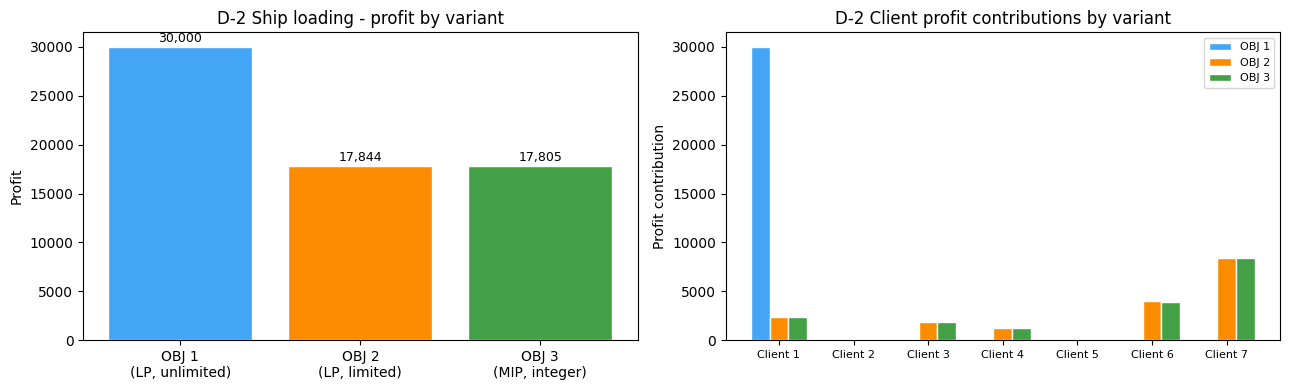

In [ ]:
if results:
    obj_labels = {1: "OBJ 1\n(LP, unlimited)", 2: "OBJ 2\n(LP, limited)", 3: "OBJ 3\n(MIP, integer)"}
    colors     = {1: "#42A5F5", 2: "#FB8C00", 3: "#43A047"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: objective comparison
    ax = axes[0]
    labels = [obj_labels[o] for o in [1,2,3]]
    values = [results[o]["sol_obj"] for o in [1,2,3]]
    bars = ax.bar(labels, values, color=[colors[o] for o in [1,2,3]], edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Profit")
    ax.set_title("D-2 Ship loading - profit by variant")

    # Right: per-client contributions per variant
    ax2 = axes[1]
    x = np.arange(1, 8)
    width = 0.25
    for i, obj in enumerate([1, 2, 3]):
        sol_load = results[obj]["sol_load"]
        contribs = [PROF[c] * sol_load.get(c, 0) for c in range(1, 8)]
        ax2.bar(x + (i-1)*width, contribs, width=width, color=colors[obj],
                edgecolor="white", label=f"OBJ {obj}")
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"Client {c}" for c in range(1, 8)], fontsize=8)
    ax2.set_ylabel("Profit contribution")
    ax2.set_title("D-2 Client profit contributions by variant")
    ax2.legend(fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping ship loading chart")

## D-3 Tank loading (MIP)

*Applications Book Chapter D, Example 3*

> **Mosel model:** [`d3tanks_p.mos`](models/loading_cutting_stock/d3tanks_p.mos)

Five tanker ships carrying chemical liquids must be unloaded into 9 storage tanks. Liquids must not be mixed. Two tanks already have partial contents. The model is solved for two objectives in sequence:

- **Objective 1:** minimize total capacity of tanks occupied (prefer filling fewer, larger tanks).
- **Objective 2:** minimize number of tanks used.

Entries of the decision variable array `ifload` are created dynamically via `create()` - only for the empty tanks. The `TINIT` and `QINIT` arrays record the initial partial contents.

**Sets:** $\text{TANKS} = 1..9$, $\text{LIQ} = \{\text{Benzol, Butanol, Propanol, Styrene, THF}\}$

**Decision variables:** $\mathit{ifload}_{l,t} \in \{0,1\}$ for $t$ with no initial contents (1 if liquid $l$ uses tank $t$)

$$
\begin{align*}
\text{Obj 1:}\quad \text{minimize} \quad & \sum_{l,t} \text{CAP}_t \cdot \mathit{ifload}_{l,t} \\
\text{Obj 2:}\quad \text{minimize} \quad & \sum_{l,t} \mathit{ifload}_{l,t} \\
\text{subject to} \quad & \sum_{l} \mathit{ifload}_{l,t} \leq 1 \quad \forall\, t \quad \text{(no mixing)} \\
                          & \sum_{t} \text{CAP}_t \cdot \mathit{ifload}_{l,t} \geq \text{REST}_l \quad \forall\, l \quad \text{(satisfy remaining quantities)}
\end{align*}
$$

where $\text{REST}_l = \text{ARR}_l - \sum_{t:\,\text{TINIT}_t=l}(\text{CAP}_t - \text{QINIT}_t)$ is the quantity not covered by the pre-filled tanks.

Define the 9 tank capacities, arriving quantities per liquid, initial tank assignments (`TINIT` and `QINIT` for the two pre-filled tanks), and pass them via `input_data`. The `LIQ` set is auto-populated from the string keys of the `ARR` dict.

In [ ]:
CAP   = {i+1: v for i,v in enumerate([500,400,400,600,600,900,800,800,800])}
ARR   = {"Benzol":1200,"Butanol":700,"Propanol":1000,"Styrene":450,"THF":1200}
TINIT = {2:"Benzol", 7:"THF"}
QINIT = {2:100, 7:300}

print("Tank capacities:", list(CAP.values()))
print("Arriving quantities:", ARR)
print("Pre-filled tanks:", {t: f"{TINIT[t]} ({QINIT[t]})" for t in TINIT})

Tank capacities: [500, 400, 400, 600, 600, 900, 800, 800, 800]
Arriving quantities: {'Benzol': 1200, 'Butanol': 700, 'Propanol': 1000, 'Styrene': 450, 'THF': 1200}
Pre-filled tanks: {2: 'Benzol (100)', 7: 'THF (300)'}


The model accepts an `OBJ` parameter (1 = minimize total capacity used, 2 = minimize number of tanks). Compile and load once, then run twice with `exec_params={"OBJ": 1}` and `exec_params={"OBJ": 2}`. Both runs return `sol_TankUse`, `sol_TankNum`, and `sol_ifload` (the detailed assignment), enabling a side-by-side comparison. Pre-filled tanks 2 (Benzol, 100) and 7 (THF, 300) are fixed and excluded from the counts.

In [ ]:
mp.compile_model(f"{MODELS}/d3tanks_p.mos", f"{MODELS}/d3tanks_p.bim")
model = mp.load_model(f"{MODELS}/d3tanks_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

prefilled_cap = sum(CAP[t] for t in QINIT)
prefilled_num = len(QINIT)

results = {}
for obj in [1, 2]:
    output = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "VARIANT": obj},
        input_data={"CAP": CAP, "ARR": ARR, "TINIT": TINIT, "QINIT": QINIT},
    )
    if model.prob_status.is_solution_available:
        results[obj] = output
    else:
        print(f"MOD={obj}: No solution found ({model.prob_status})")

obj_labels = {1: "min capacity", 2: "min tanks"}
for obj, output in results.items():
    sol_ifload  = {(l, t): v for (l, t), v in output["sol_ifload"].items() if v > 0.5}
    sol_TankUse = output["sol_TankUse"]
    sol_TankNum = output["sol_TankNum"]
    print(f"OBJ {obj} ({obj_labels[obj]}):")
    print(f"  Capacity of newly used tanks: {sol_TankUse:.0f}  (total incl. pre-filled: {sol_TankUse + prefilled_cap:.0f})")
    print(f"  Number  of newly used tanks:  {sol_TankNum:.0f}  (total incl. pre-filled: {sol_TankNum + prefilled_num:.0f})")
    for t in range(1, 10):
        if t in QINIT:
            print(f"    Tank {t} (cap={CAP[t]:>4}): {TINIT[t]} [pre-filled, qty={QINIT[t]}]")
        else:
            liq_here = [l for (l, tk) in sol_ifload if tk == t]
            print(f"    Tank {t} (cap={CAP[t]:>4}): {liq_here[0] if liq_here else 'empty'}")
    print()

OBJ 1 (min capacity):
  Capacity of newly used tanks: 4000  (total incl. pre-filled: 5200)
  Number  of newly used tanks:  6  (total incl. pre-filled: 8)
    Tank 1 (cap= 500): Styrene
    Tank 2 (cap= 400): Benzol [pre-filled, qty=100]
    Tank 3 (cap= 400): Propanol
    Tank 4 (cap= 600): Propanol
    Tank 5 (cap= 600): empty
    Tank 6 (cap= 900): Benzol
    Tank 7 (cap= 800): THF [pre-filled, qty=300]
    Tank 8 (cap= 800): Butanol
    Tank 9 (cap= 800): THF

OBJ 2 (min tanks):
  Capacity of newly used tanks: 4000  (total incl. pre-filled: 5200)
  Number  of newly used tanks:  6  (total incl. pre-filled: 8)
    Tank 1 (cap= 500): Styrene
    Tank 2 (cap= 400): Benzol [pre-filled, qty=100]
    Tank 3 (cap= 400): Propanol
    Tank 4 (cap= 600): Propanol
    Tank 5 (cap= 600): empty
    Tank 6 (cap= 900): Benzol
    Tank 7 (cap= 800): THF [pre-filled, qty=300]
    Tank 8 (cap= 800): Butanol
    Tank 9 (cap= 800): THF



Side-by-side bar charts comparing the two objective assignments. Each tank is colored by its assigned liquid. Pre-filled tanks are shown with a hatched pattern; empty tanks are gray.

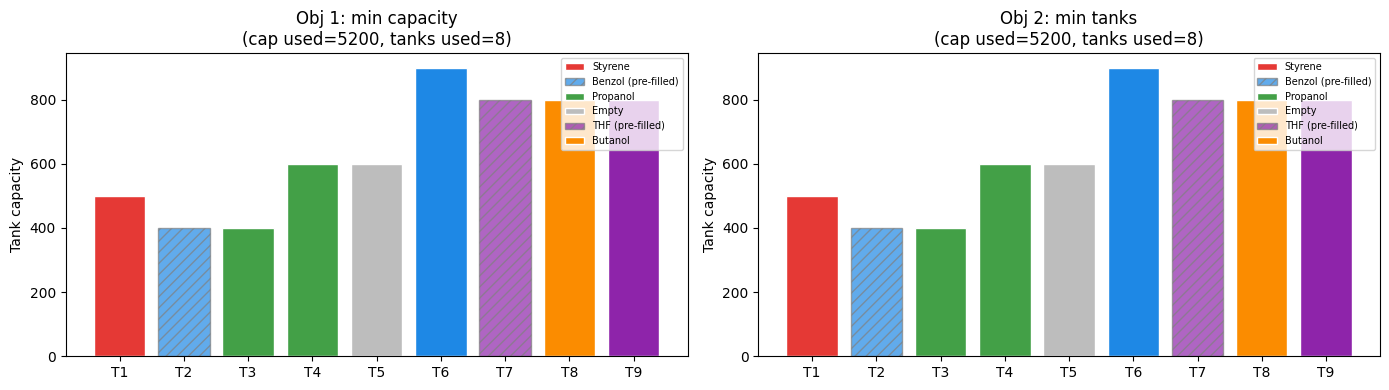

In [ ]:
if results:
    liq_names  = list(ARR.keys())
    liq_colors = dict(zip(liq_names, ["#1E88E5","#FB8C00","#43A047","#E53935","#8E24AA"]))
    obj_labels = {1: "Obj 1: min capacity", 2: "Obj 2: min tanks"}

    def draw_tanks(ax, assigned, sol_TankUse, sol_TankNum, title):
        seen = set()
        for t in range(1, 10):
            cap = CAP[t]
            if t in QINIT:
                liq = TINIT[t]
                label = f"{liq} (pre-filled)" if liq not in seen else ""
                seen.add(liq)
                ax.bar(t, cap, color=liq_colors.get(liq, "#90CAF9"),
                       edgecolor="gray", hatch="///", alpha=0.7, label=label)
            else:
                liq_here = [l for (l, tk) in assigned if tk == t]
                if liq_here:
                    liq = liq_here[0]
                    label = liq if liq not in seen else ""
                    seen.add(liq)
                    ax.bar(t, cap, color=liq_colors.get(liq, "#90CAF9"), edgecolor="white", label=label)
                else:
                    label = "Empty" if "Empty" not in seen else ""
                    seen.add("Empty")
                    ax.bar(t, cap, color="#BDBDBD", edgecolor="white", label=label)
        ax.set_xticks(range(1, 10))
        ax.set_xticklabels([f"T{t}" for t in range(1, 10)])
        ax.set_ylabel("Tank capacity")
        ax.set_title(f"{title}\n(cap used={sol_TankUse + prefilled_cap:.0f}, tanks used={sol_TankNum + prefilled_num:.0f})")
        ax.legend(loc="upper right", fontsize=7)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for obj, ax in zip([1, 2], axes):
        output   = results[obj]
        assigned = {(l, t): v for (l, t), v in output["sol_ifload"].items() if v > 0.5}
        draw_tanks(ax, assigned, output["sol_TankUse"], output["sol_TankNum"], obj_labels[obj])
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping tank chart")

## D-4 Bin packing: file backup (MIP)

*Applications Book Chapter D, Example 4*

> **Mosel model:** [`d4backup_p.mos`](models/loading_cutting_stock/d4backup_p.mos)

Sixteen files of varying sizes must be backed up onto external storage disks, each with capacity 1440 MB. The goal is to minimize the number of disks used. This is the classic bin-packing problem. The model computes the minimum number of disks required (`ND`) as an upper bound before building the MIP.

**Sets:** $\text{FILES} = 1..16$, $\text{DISKS} = 1..\text{ND}$

**Decision variables:** $\mathit{ifsave}_{f,d} \in \{0,1\}$ (1 if file $f$ saved on disk $d$); $\mathit{diskuse} \geq 0$ (index of last disk used)

$$
\begin{align*}
\text{minimize}   \quad & \mathit{diskuse} \\
\text{subject to} \quad & \mathit{diskuse} \geq \sum_d d \cdot \mathit{ifsave}_{f,d} \quad \forall\, f \\
                          & \sum_d \mathit{ifsave}_{f,d} = 1 \quad \forall\, f \quad \text{(each file on one disk)} \\
                          & \sum_f \text{SIZE}_f \cdot \mathit{ifsave}_{f,d} \leq \text{CAP} \quad \forall\, d
\end{align*}
$$

Define file sizes and disk capacity in Python. `SIZE` is a 1-indexed dict; `CAP` is a scalar. The model computes `ND` internally using `ceil(sum(SIZE)/CAP)`.

In [ ]:
SIZE = {i+1: v for i,v in enumerate([46,55,62,87,108,114,137,164,253,364,372,388,406,432,461,851])}
CAP  = 1440

total = sum(SIZE.values())
nd_lb = -(-total // CAP)   # ceiling division
print(f"Total file size: {total} MB, disk capacity: {CAP} MB")
print(f"Lower bound on disks needed: {nd_lb}")

Total file size: 4300 MB, disk capacity: 1440 MB
Lower bound on disks needed: 3


Run `d4backup_p.mos` using the single execution command. The model computes `ND` internally and builds `DISKS = 1..ND` before declaring `ifsave`. After solving, `obj_val` is the number of disks used and `sol_ifsave` is the full assignment matrix.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/d4backup_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"SIZE": SIZE, "CAP": CAP},
)

if output is not None:
    obj_val_d4  = output["obj_val"]
    sol_ifsave  = output["sol_ifsave"]   # dict: (file, disk) -> real

    nd_used = int(round(obj_val_d4))
    print(f"Minimum number of disks: {nd_used}")
    print()
    for d in range(1, nd_used + 1):
        files = [f for f in range(1, 17) if sol_ifsave.get((f, d), 0) > 0.5]
        used  = sum(SIZE[f] for f in files)
        print(f"  Disk {d}: files {files}  used={used} MB  free={CAP-used} MB")
else:
    print("No output returned")

Minimum number of disks: 3

  Disk 1: files [6, 15, 16]  used=1426 MB  free=14 MB
  Disk 2: files [1, 8, 12, 13, 14]  used=1436 MB  free=4 MB
  Disk 3: files [2, 3, 4, 5, 7, 9, 10, 11]  used=1438 MB  free=2 MB


Horizontal stacked bar chart of disk utilization. Each disk is a bar; segments are individual files (width = file size in MB). The dashed line marks the 1440 MB capacity.

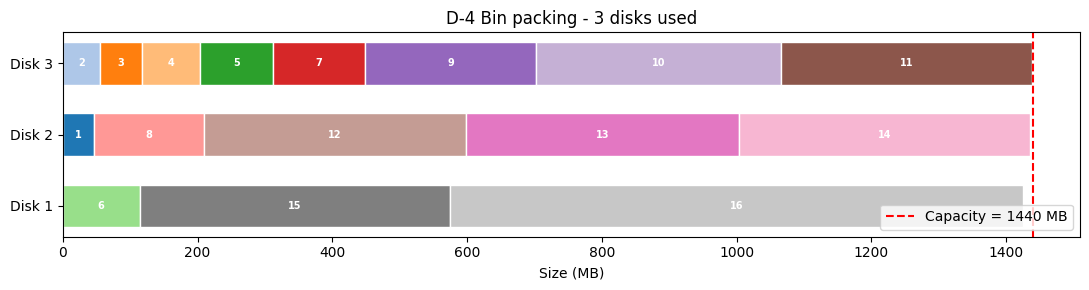

In [ ]:
if "sol_ifsave" in locals():
    nd_used = int(round(obj_val_d4))
    file_colors = plt.cm.tab20.colors

    fig, ax = plt.subplots(figsize=(11, max(3, nd_used * 0.6 + 1)))
    for d in range(1, nd_used + 1):
        files = sorted([f for f in range(1, 17) if sol_ifsave.get((f, d), 0) > 0.5])
        left = 0
        for f in files:
            sz = SIZE[f]
            ax.barh(d-1, sz, left=left, color=file_colors[(f-1) % 20],
                    edgecolor="white", height=0.6)
            ax.text(left + sz/2, d-1, str(f), ha="center", va="center",
                    fontsize=7, fontweight="bold", color="white")
            left += sz

    ax.axvline(CAP, color="red", linestyle="--", linewidth=1.5, label=f"Capacity = {CAP} MB")
    ax.set_yticks(range(nd_used))
    ax.set_yticklabels([f"Disk {d}" for d in range(1, nd_used + 1)])
    ax.set_xlabel("Size (MB)")
    ax.set_title(f"D-4 Bin packing - {nd_used} disks used")
    ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping backup chart")

## D-5 Sheet metal cutting (MIP)

*Applications Book Chapter D, Example 5*

> **Mosel model:** [`d5cutsh_p.mos`](models/loading_cutting_stock/d5cutsh_p.mos)

A sheet metal shop cuts large sheets into 4 smaller sizes. There are 16 pre-computed cutting patterns. The goal is to satisfy demand for each size using the minimum number of large sheets. This is a covering (cutting stock) problem.

**Sets:** $\text{PATTERNS} = 1..16$, $\text{SIZES} = 1..4$

**Decision variables:** $\mathit{use}_p \in \mathbb{Z}_{\geq 0}$ (how many times to cut pattern $p$)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p} \mathit{use}_p \\
\text{subject to} \quad & \sum_{p} \text{CUT}_{s,p} \cdot \mathit{use}_p \geq \text{DEM}_s \quad \forall\, s \in \text{SIZES}
\end{align*}
$$

Define demands `DEM` and the 4x16 cutting matrix `CUT` in Python. `CUT` is passed as a `pd.DataFrame` with size indices as rows and pattern indices as columns. Passing a DataFrame directly as `input_data` is a convenient way to supply 2D data without manually constructing a tuple-keyed dict.

In [ ]:
DEM = {1: 8, 2: 13, 3: 5, 4: 15}

cut_rows = [
    [1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0],   # size 1
    [2,1,0,2,1,0,3,2,1,0,5,4,3,2,1,0],   # size 2
    [0,0,0,2,2,2,1,1,1,1,0,0,0,0,0,0],   # size 3
    [0,1,3,0,1,3,0,2,3,5,0,1,3,5,6,8],   # size 4
]
CUT = pd.DataFrame(cut_rows, index=[1,2,3,4], columns=range(1,17))
CUT.index.name   = "Size"
CUT.columns.name = "Pattern"

print("Demands:", DEM)
print("\nCutting patterns (rows=sizes, columns=patterns):")
print(CUT.to_string())

Demands: {1: 8, 2: 13, 3: 5, 4: 15}

Cutting patterns (rows=sizes, columns=patterns):
Pattern  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
Size                                                                   
1         1   1   1   0   0   0   0   0   0   0   0   0   0   0   0   0
2         2   1   0   2   1   0   3   2   1   0   5   4   3   2   1   0
3         0   0   0   2   2   2   1   1   1   1   0   0   0   0   0   0
4         0   1   3   0   1   3   0   2   3   5   0   1   3   5   6   8


Run the model passing `CUT` as a DataFrame in `input_data`. MoselPy maps the DataFrame's row/column indices directly to the Mosel 2D array. After solving, `sol_use` is a dict mapping pattern index to number of times it is used.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/d5cutsh_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DEM": DEM, "CUT": CUT},
)

if output is not None:
    obj_val_d5 = output["obj_val"]
    sol_use_d5 = output["sol_use"]   # dict: pattern -> real

    print(f"Minimum large sheets required: {obj_val_d5:.0f}")
    print()
    print("Patterns used:")
    for p in range(1, 17):
        qty = sol_use_d5.get(p, 0)
        if qty > 0.5:
            pieces = [f"size {s}: {CUT.at[s,p]}" for s in range(1,5) if CUT.at[s,p] > 0]
            print(f"  Pattern {p:2d} x {qty:.0f}:  {', '.join(pieces)}")
    print()
    for s in range(1, 5):
        produced = sum(CUT.at[s,p] * sol_use_d5.get(p, 0) for p in range(1, 17))
        print(f"  Size {s}: demand={DEM[s]}, produced={produced:.0f}")
else:
    print("No output returned")

Minimum large sheets required: 11

Patterns used:
  Pattern  1 x 6:  size 1: 1, size 2: 2
  Pattern  2 x 1:  size 1: 1, size 2: 1, size 4: 1
  Pattern  3 x 1:  size 1: 1, size 4: 3
  Pattern  6 x 2:  size 3: 2, size 4: 3
  Pattern 10 x 1:  size 3: 1, size 4: 5

  Size 1: demand=8, produced=8
  Size 2: demand=13, produced=13
  Size 3: demand=5, produced=5
  Size 4: demand=15, produced=15


Heatmap of the 4x16 cutting pattern matrix. Darker cells indicate more pieces of that size cut per sheet. Patterns actually used in the solution are highlighted with a border.

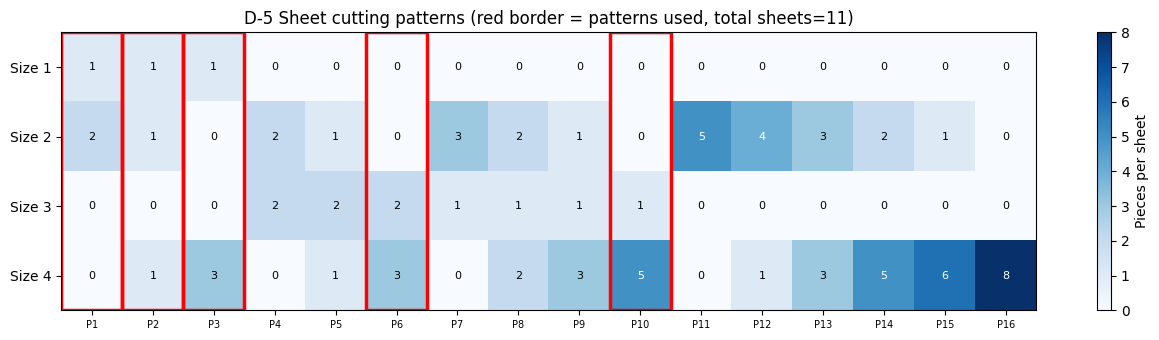

In [ ]:
if "sol_use_d5" in locals():
    cut_matrix = CUT.values  # shape (4, 16)
    used_patterns = [p for p in range(1, 17) if sol_use_d5.get(p, 0) > 0.5]

    fig, ax = plt.subplots(figsize=(13, 3.5))
    im = ax.imshow(cut_matrix, cmap="Blues", aspect="auto", vmin=0)
    plt.colorbar(im, ax=ax, label="Pieces per sheet")

    for s_idx in range(4):
        for p_idx in range(16):
            val = cut_matrix[s_idx, p_idx]
            ax.text(p_idx, s_idx, str(val), ha="center", va="center",
                    fontsize=8, color="white" if val > 3 else "black")

    # Highlight used patterns
    for p in used_patterns:
        p_idx = p - 1
        ax.add_patch(plt.Rectangle((p_idx - 0.5, -0.5), 1, 4,
                                   fill=False, edgecolor="red", linewidth=2.5))

    ax.set_xticks(range(16))
    ax.set_xticklabels([f"P{p}" for p in range(1, 17)], fontsize=7)
    ax.set_yticks(range(4))
    ax.set_yticklabels([f"Size {s}" for s in range(1, 5)])
    ax.set_title(f"D-5 Sheet cutting patterns (red border = patterns used, total sheets={obj_val_d5:.0f})")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping pattern heatmap")

## D-6 Cutting steel bars (MIP)

*Applications Book Chapter D, Example 6*

> **Mosel model:** [`d6cutbar_p.mos`](models/loading_cutting_stock/d6cutbar_p.mos)

A company produces school desks in three heights (40, 60, 70 cm). Desk legs are cut from steel bars of two lengths (150 cm and 200 cm). Each bar has its own set of pre-computed patterns. The goal is to minimize total material waste (trim loss).

Note that `SIZES` is declared as `set of integer` in the Mosel model, which is more general than a range. When passing `DEM` from Python as a dict keyed by integer, MoselPy automatically populates `SIZES` from the dict keys.

**Sets:** $\text{PAT1} = 1..6$, $\text{PAT2} = 7..12$, $\text{PATTERNS} = \text{PAT1} \cup \text{PAT2}$, $\text{SIZES} = \{40, 60, 70\}$

**Decision variables:** $\mathit{use}_p \in \mathbb{Z}_{\geq 0}$ (how many times to use pattern $p$)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p \in \text{PAT1}} \text{LEN}_1 \cdot \mathit{use}_p + \sum_{p \in \text{PAT2}} \text{LEN}_2 \cdot \mathit{use}_p - \sum_{s \in \text{SIZES}} 4 \cdot \text{DEM}_s \cdot s \\
\text{subject to} \quad & \sum_{p \in \text{PATTERNS}} \text{CUT}_{p,s} \cdot \mathit{use}_p \geq 4 \cdot \text{DEM}_s \quad \forall\, s \in \text{SIZES}
\end{align*}
$$

The factor of 4 accounts for 4 legs per desk. The objective is the total bar material used minus total leg material needed.

Define demands by desk height and the cutting patterns in Python. The data is defined here for readability, but the model reads from the `.dat` file. Unlike `set of string`, a `set of integer` index (`SIZES`) cannot be initialized via the `moselpy:` driver - this is the same limitation as `array of set of integer` seen in `a5mine2_p` and `b1stadium2_p`.

In [ ]:
DEM = {40: 108, 60: 125, 70: 100}
LEN = {1: 150, 2: 200}
CUT = {
    (1,40):0,(1,60):0,(1,70):2,
    (2,40):0,(2,60):1,(2,70):1,
    (3,40):2,(3,60):0,(3,70):1,
    (4,40):0,(4,60):2,(4,70):0,
    (5,40):2,(5,60):1,(5,70):0,
    (6,40):3,(6,60):0,(6,70):0,
    (7,40):0,(7,60):1,(7,70):2,
    (8,40):0,(8,60):2,(8,70):1,
    (9,40):1,(9,60):0,(9,70):2,
    (10,40):3,(10,60):0,(10,70):1,
    (11,40):0,(11,60):3,(11,70):0,
    (12,40):5,(12,60):0,(12,70):0,
}

print("Demands by height (x4 legs per desk):")
for s, d in DEM.items():
    print(f"  Height {s} cm: {d} desks = {4*d} legs")
print(f"\nBar lengths: {LEN}")

Demands by height (x4 legs per desk):
  Height 40 cm: 108 desks = 432 legs
  Height 60 cm: 125 desks = 500 legs
  Height 70 cm: 100 desks = 400 legs

Bar lengths: {1: 150, 2: 200}


Run `d6cutbar_p.mos` reading from the `.dat` file. After solving, `obj_val` is the trim loss in cm and `sol_use` maps pattern index to usage count.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/d6cutbar_p.mos",
    exec_params={"DATASOURCE": f"{DATA}/d6cutbar_p.dat", "OUTFILE": "moselpy:"},
)

if output is not None:
    obj_val_d6 = output["obj_val"]
    sol_use_d6 = output["sol_use"]   # dict: pattern -> real

    short_used = sum(sol_use_d6.get(p, 0) for p in range(1, 7))
    long_used  = sum(sol_use_d6.get(p, 0) for p in range(7, 13))
    print(f"Total trim loss: {obj_val_d6:.0f} cm")
    print(f"Short bars (150 cm) used: {short_used:.0f}")
    print(f"Long bars  (200 cm) used: {long_used:.0f}")
    print()
    print("Patterns used:")
    for p in range(1, 13):
        qty = sol_use_d6.get(p, 0)
        if qty > 0.5:
            bar_len = LEN[1] if p <= 6 else LEN[2]
            pieces  = [f"{s}cm x{CUT.get((p,s),0)}" for s in [40,60,70] if CUT.get((p,s),0)>0]
            print(f"  Pattern {p:2d} (bar={bar_len}cm) x {qty:.0f}:  {', '.join(pieces)}")
    print()
    for s in [40, 60, 70]:
        produced = sum(CUT.get((p,s),0)*sol_use_d6.get(p,0) for p in range(1,13))
        needed   = 4 * DEM[s]
        print(f"  Height {s} cm: {produced:.0f} legs produced, {needed} needed")
else:
    print("No output returned")

Total trim loss: 2020 cm
Short bars (150 cm) used: 2
Long bars  (200 cm) used: 385

Patterns used:
  Pattern  2 (bar=150cm) x 1:  60cm x1, 70cm x1
  Pattern  3 (bar=150cm) x 1:  40cm x2, 70cm x1
  Pattern  7 (bar=200cm) x 198:  60cm x1, 70cm x2
  Pattern  8 (bar=200cm) x 2:  60cm x2, 70cm x1
  Pattern 11 (bar=200cm) x 99:  60cm x3
  Pattern 12 (bar=200cm) x 86:  40cm x5

  Height 40 cm: 432 legs produced, 432 needed
  Height 60 cm: 500 legs produced, 500 needed
  Height 70 cm: 400 legs produced, 400 needed
